In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from catboost import Pool, CatBoostRegressor
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import utils_ml
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import gc
gc.collect()

In [3]:
plt.style.use('tableau-colorblind10')
def plot_style():
    font_size       = 12
    dpi             = 200

    params = {'figure.dpi': dpi,
              'savefig.dpi': dpi,
              'font.size': font_size,
              'font.family': "serif",
              'figure.titlesize': font_size,
              'legend.fontsize': font_size,
              'axes.labelsize': font_size,
              'axes.titlesize': font_size,
              'xtick.labelsize': font_size,
              'ytick.labelsize': font_size,
              'text.usetex': True,
             }

    plt.rcParams.update(params)
plot_style()

In [4]:
# Load and concatenate all features
file_prefix = "dataExt/P"
file_suffix = "_intensity.pkl"
num_files = 35

old_label_arr = np.array([np.tile(i,np.load(f"{file_prefix}{0:02d}{file_suffix}", allow_pickle=True).shape[0]) for i in np.arange(num_files)]).flatten()

# Define the mapping from class labels (0 to 7) to the new 3-element array format
# where each element in the array represents the number of poles on [bt], [bb], and [tb]
class_to_poles = {
    0: [0, 0, 0],  # 1 pole on [bt]
    1: [1, 0, 0],  # 1 pole on [bb]
    2: [0, 1, 0],  # 1 pole on [tb]
    3: [0, 0, 1],  # 1 pole on [bt] and 1 pole on [bb]
    4: [2, 0, 0],  # 1 pole on [bb] and 1 pole on [tb]
    5: [0, 2, 0],  # 1 pole on each of [bt], [bb], and [tb]
    6: [0, 0, 2],  # 2 poles on [bb] and 1 pole on [tb]
    7: [1, 1, 0],   # 1 pole on [bb] and 2 poles on [tb]
    8: [1, 0, 1],
    9: [0, 1, 1],
    10: [3, 0, 0],
    11: [0, 3, 0],
    12: [0, 0, 3],
    13: [2, 1, 0],
    14: [2, 0, 1],
    15: [1, 2, 0],
    16: [0, 2, 1],
    17: [1, 0, 2],
    18: [0, 1, 2],
    19: [1, 1, 1],
    20: [4, 0, 0],
    21: [0, 4, 0],
    22: [0, 0, 4],
    23: [3, 1, 0],
    24: [3, 0, 1],
    25: [1, 3, 0],
    26: [0, 3, 1],
    27: [1, 0, 3],
    28: [0, 1, 3],
    29: [2, 2, 0],
    30: [2, 0, 2],
    31: [0, 2, 2],
    32: [2, 1, 1],
    33: [1, 2, 1],
    34: [1, 1, 2],
}

new_label_arr = utils_ml.convert_labels(old_label_arr, class_to_poles)

print("Old Labels:\n", old_label_arr)
print("New Labels:\n", new_label_arr)

# Later, load the saved array in memory-mapped mode
features_memmap = np.load('dataExt/features_filtered.npy', mmap_mode='r+')

X_train_new, X_test_new, y_train, y_test = train_test_split(features_memmap, new_label_arr, test_size=0.1, random_state=42)

Old Labels:
 [ 0  0  0 ... 34 34 34]
New Labels:
 [[0 0 0]
 [0 0 0]
 [0 0 0]
 ...
 [1 1 2]
 [1 1 2]
 [1 1 2]]


In [5]:
# Train Pool for CatBoost (multi-output regression requires separate models per target)
models = []
preds = []
data_uncertainty = []
knowledge_uncertainty = []

for i in range(y_train.shape[1]):
    train_pool = Pool(X_train_new, y_train[:, i])
    val_pool = Pool(X_test_new, y_test[:, i])

    model = CatBoostRegressor(
        iterations=1000,
        learning_rate=0.1,
        loss_function='RMSEWithUncertainty',
        subsample=0.5,
        early_stopping_rounds=10,
        bootstrap_type='Bernoulli',
        random_seed=0,
        verbose=100
    )
    model.fit(train_pool, eval_set=val_pool, use_best_model=False)
    models.append(model)

    # Generate predictions with uncertainty
    pred = model.virtual_ensembles_predict(X_test_new, prediction_type='TotalUncertainty', virtual_ensembles_count=10)
    preds.append(pred[:, 0])  # Mean predictions
    data_uncertainty.append(pred[:, 2])  # Data uncertainty
    knowledge_uncertainty.append(pred[:, 1])  # Knowledge uncertainty

# Convert lists to arrays for easier manipulation
preds = np.column_stack(preds)
data_uncertainty = np.column_stack(data_uncertainty)
knowledge_uncertainty = np.column_stack(knowledge_uncertainty)


0:	learn: 1.3209448	test: 1.3245045	best: 1.3245045 (0)	total: 330ms	remaining: 5m 29s
100:	learn: -0.6434579	test: -0.6382798	best: -0.6382798 (100)	total: 21.4s	remaining: 3m 10s
200:	learn: -0.8466693	test: -0.8254753	best: -0.8255636 (199)	total: 41.1s	remaining: 2m 43s
300:	learn: -0.9155501	test: -0.8869918	best: -0.8869918 (300)	total: 59.7s	remaining: 2m 18s
400:	learn: -0.9674672	test: -0.9304724	best: -0.9305454 (397)	total: 1m 18s	remaining: 1m 57s
500:	learn: -1.0055306	test: -0.9603420	best: -0.9603420 (500)	total: 1m 37s	remaining: 1m 36s
Stopped by overfitting detector  (10 iterations wait)

bestTest = -0.9800624683
bestIteration = 574

0:	learn: 1.4190891	test: 1.4201857	best: 1.4201857 (0)	total: 224ms	remaining: 3m 43s
100:	learn: 0.4366093	test: 0.4379474	best: 0.4379474 (100)	total: 19.8s	remaining: 2m 55s
200:	learn: 0.3855112	test: 0.3941725	best: 0.3941725 (200)	total: 38.7s	remaining: 2m 33s
300:	learn: 0.3544237	test: 0.3706101	best: 0.3706101 (300)	total: 56.5

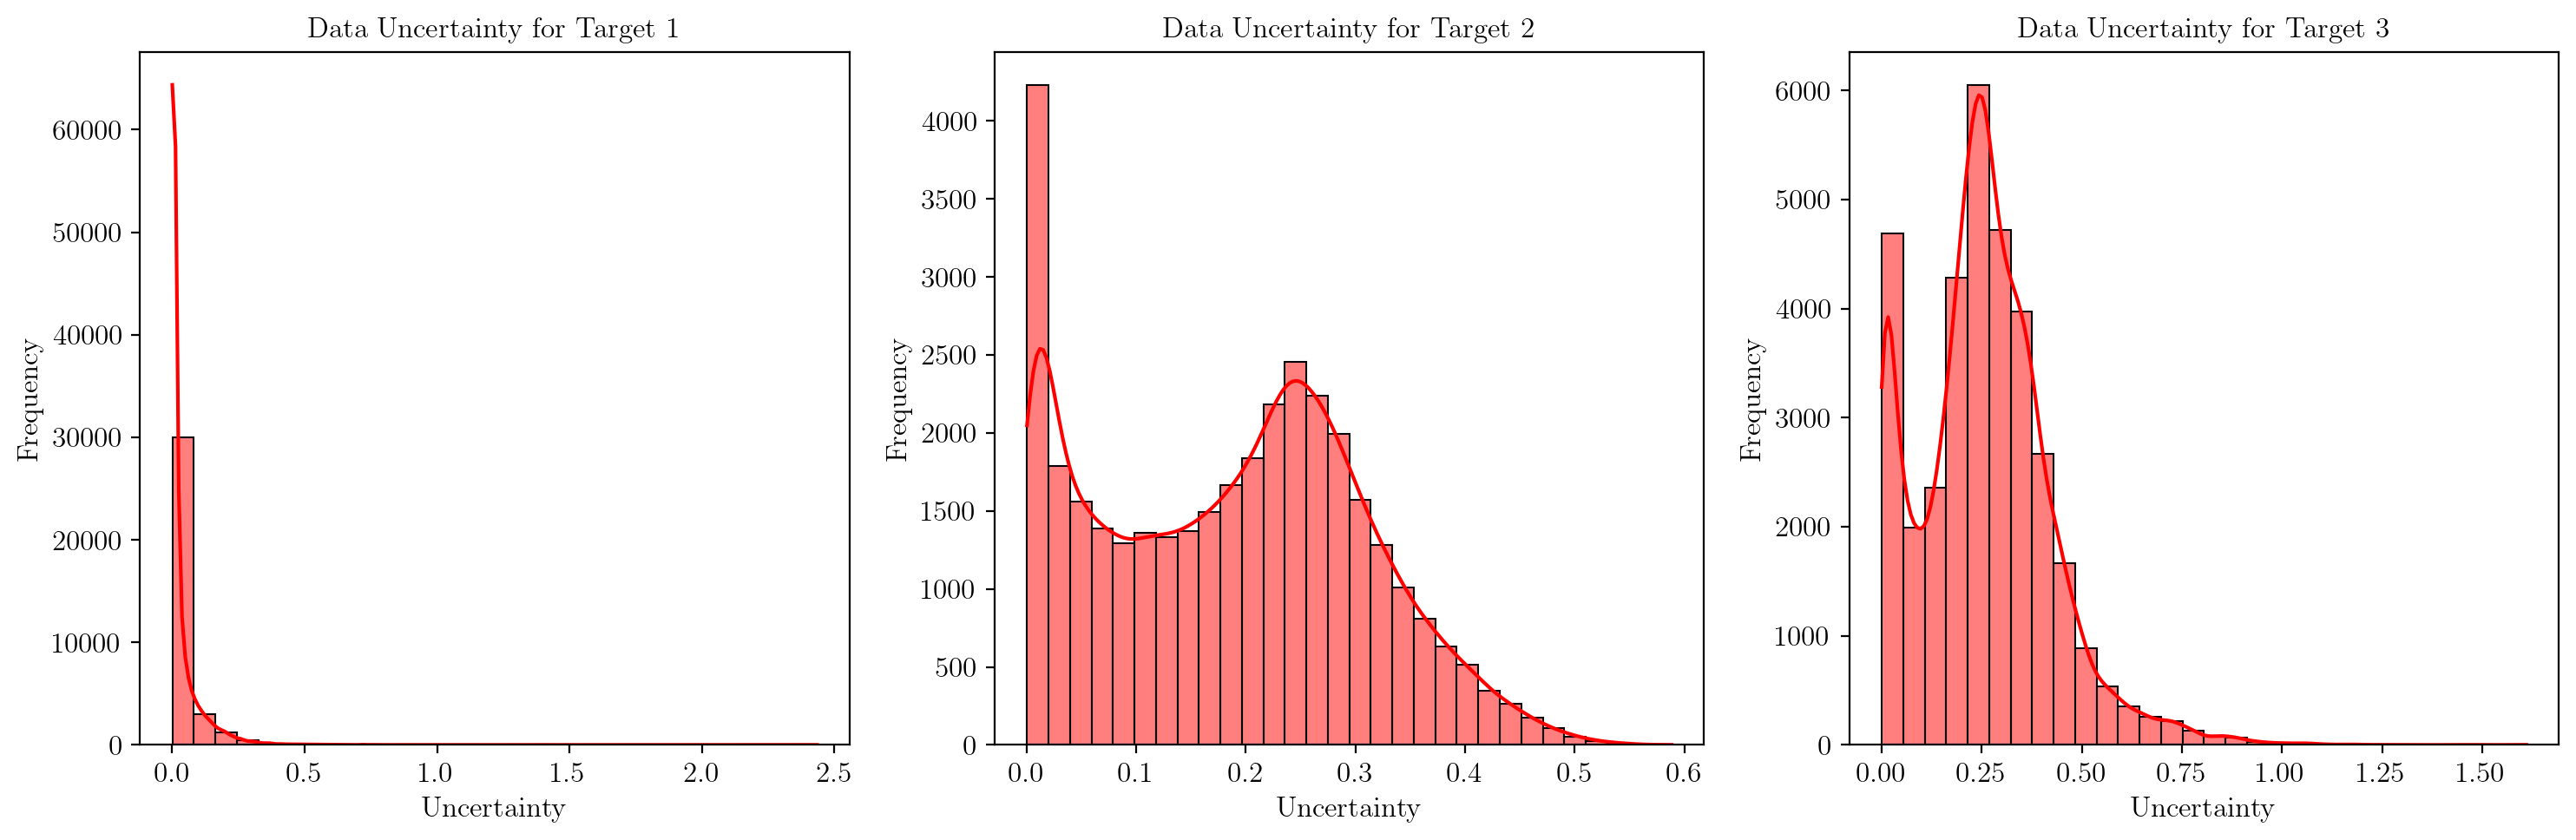

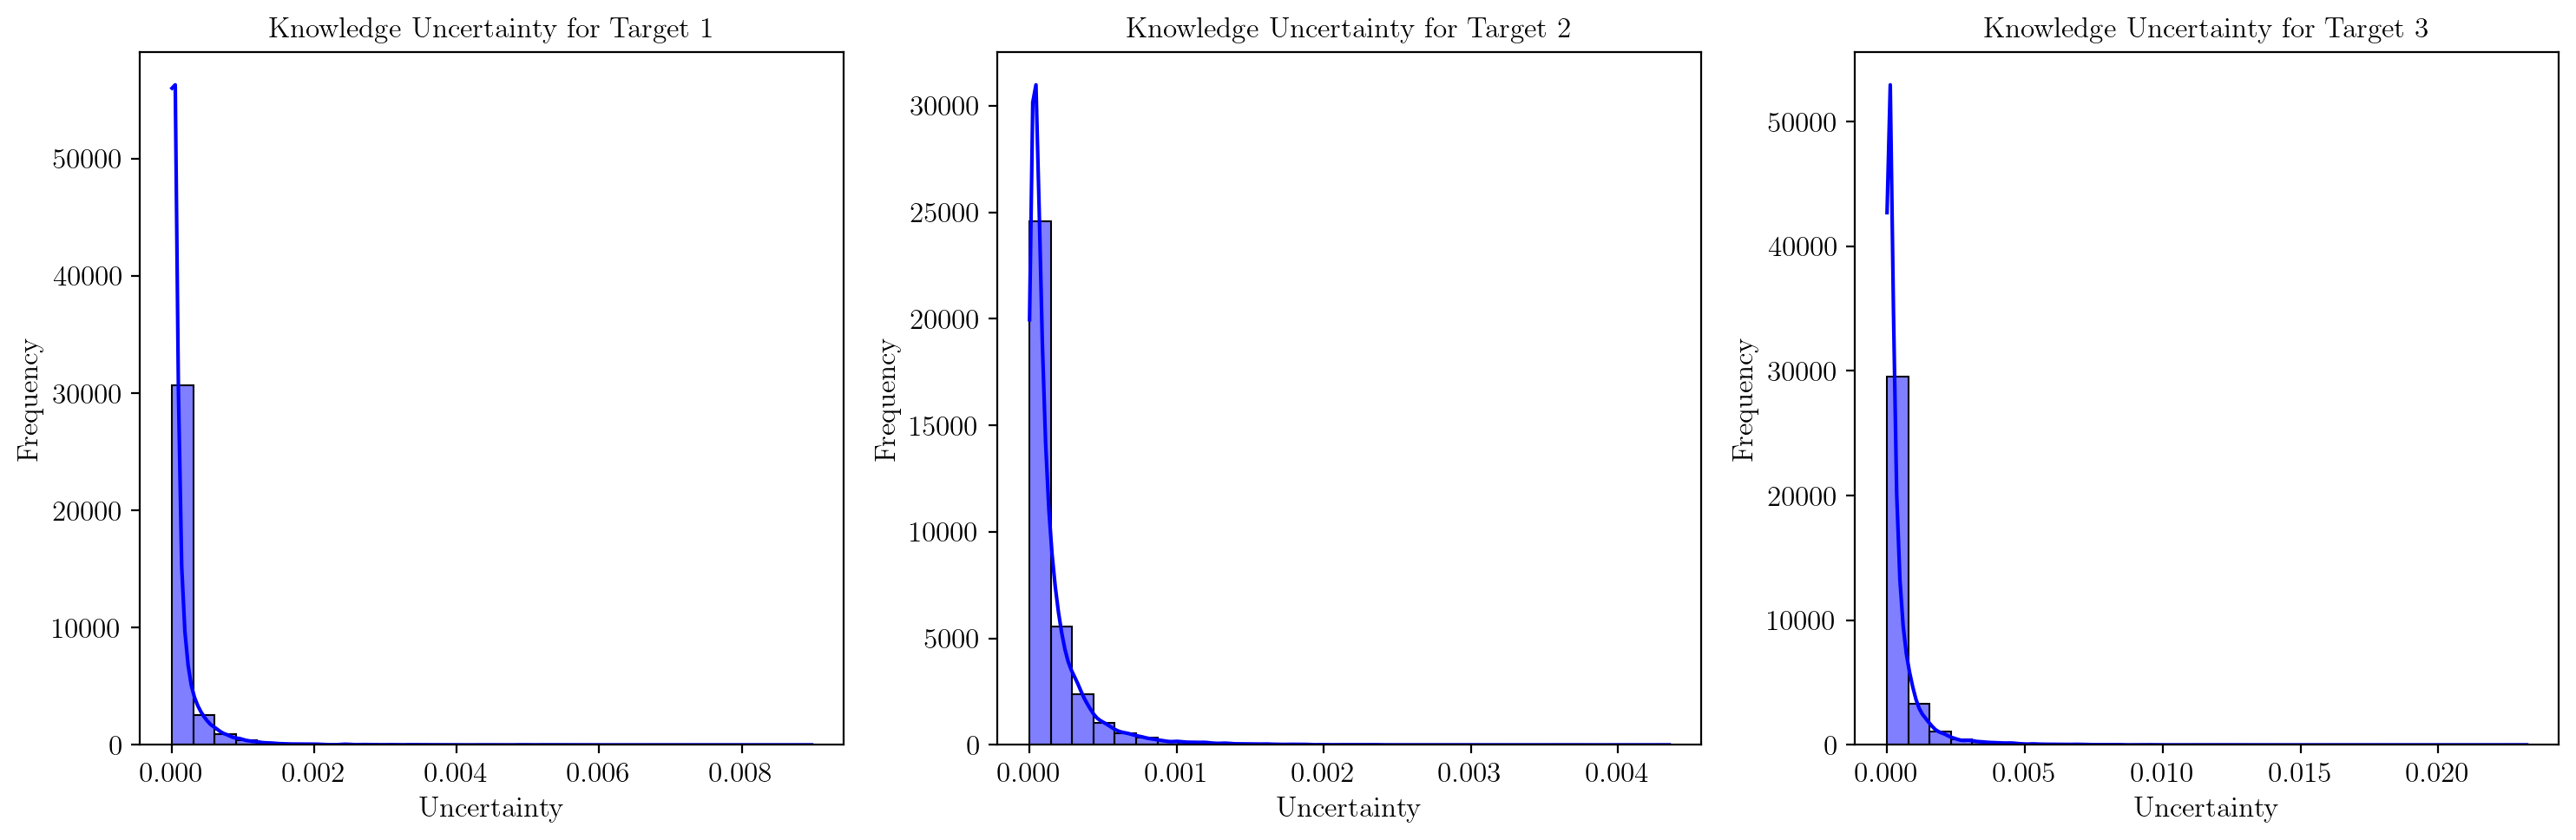

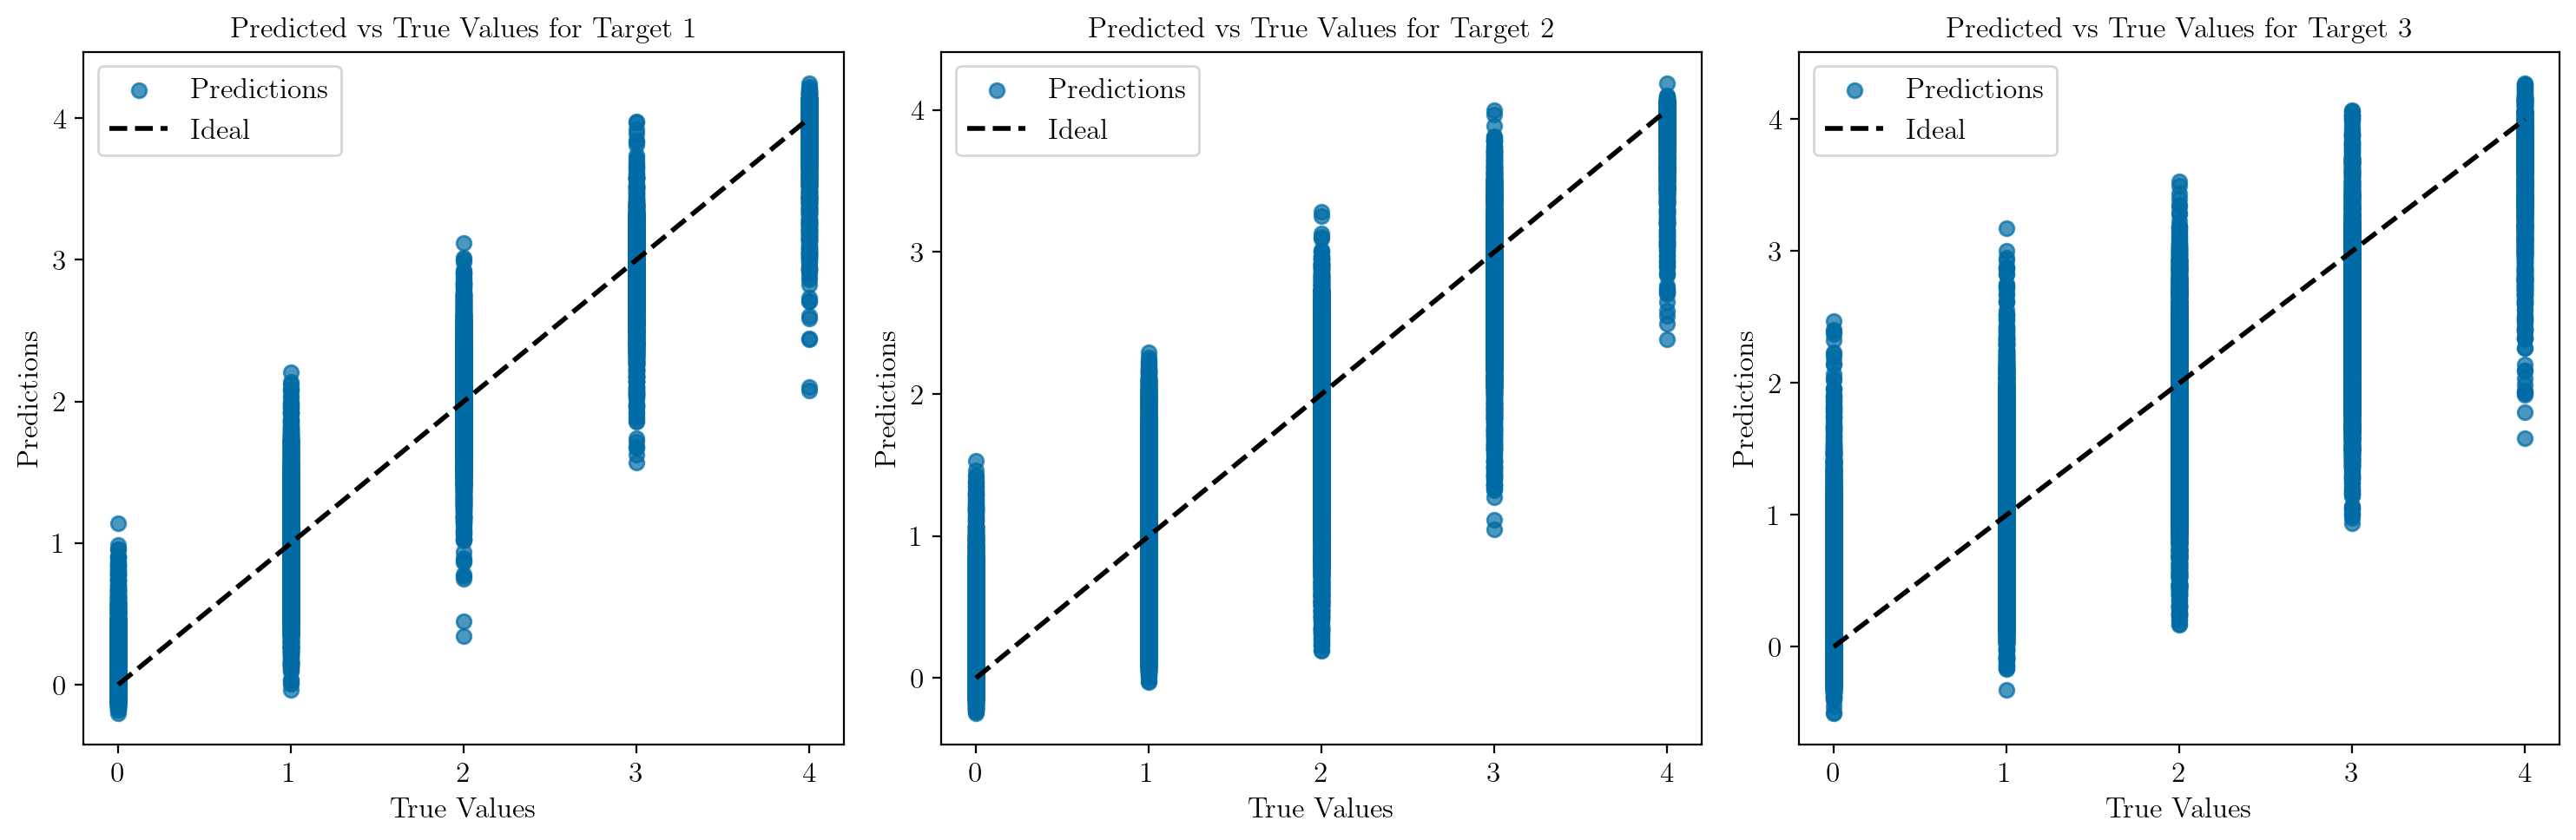

In [6]:

# Aggregate plots for data uncertainty
plt.figure(figsize=(15, 5))
for i in range(y_train.shape[1]):
    plt.subplot(1, 3, i + 1)
    sns.histplot(data_uncertainty[:, i], kde=True, bins=30, color='red')
    plt.title(f"Data Uncertainty for Target {i+1}")
    plt.xlabel("Uncertainty")
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Aggregate plots for knowledge uncertainty
plt.figure(figsize=(15, 5))
for i in range(y_train.shape[1]):
    plt.subplot(1, 3, i + 1)
    sns.histplot(knowledge_uncertainty[:, i], kde=True, bins=30, color='blue')
    plt.title(f"Knowledge Uncertainty for Target {i+1}")
    plt.xlabel("Uncertainty")
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Aggregate scatter plots for predictions vs. true values
plt.figure(figsize=(15, 5))
for i in range(y_train.shape[1]):
    plt.subplot(1, 3, i + 1)
    plt.scatter(y_test[:, i], preds[:, i], alpha=0.7, label="Predictions")
    plt.plot([y_test[:, i].min(), y_test[:, i].max()], [y_test[:, i].min(), y_test[:, i].max()], 'k--', lw=2, label="Ideal")
    plt.title(f"Predicted vs True Values for Target {i+1}")
    plt.xlabel("True Values")
    plt.ylabel("Predictions")
    plt.legend()
plt.tight_layout()
plt.show()

# Uncer vs MSE

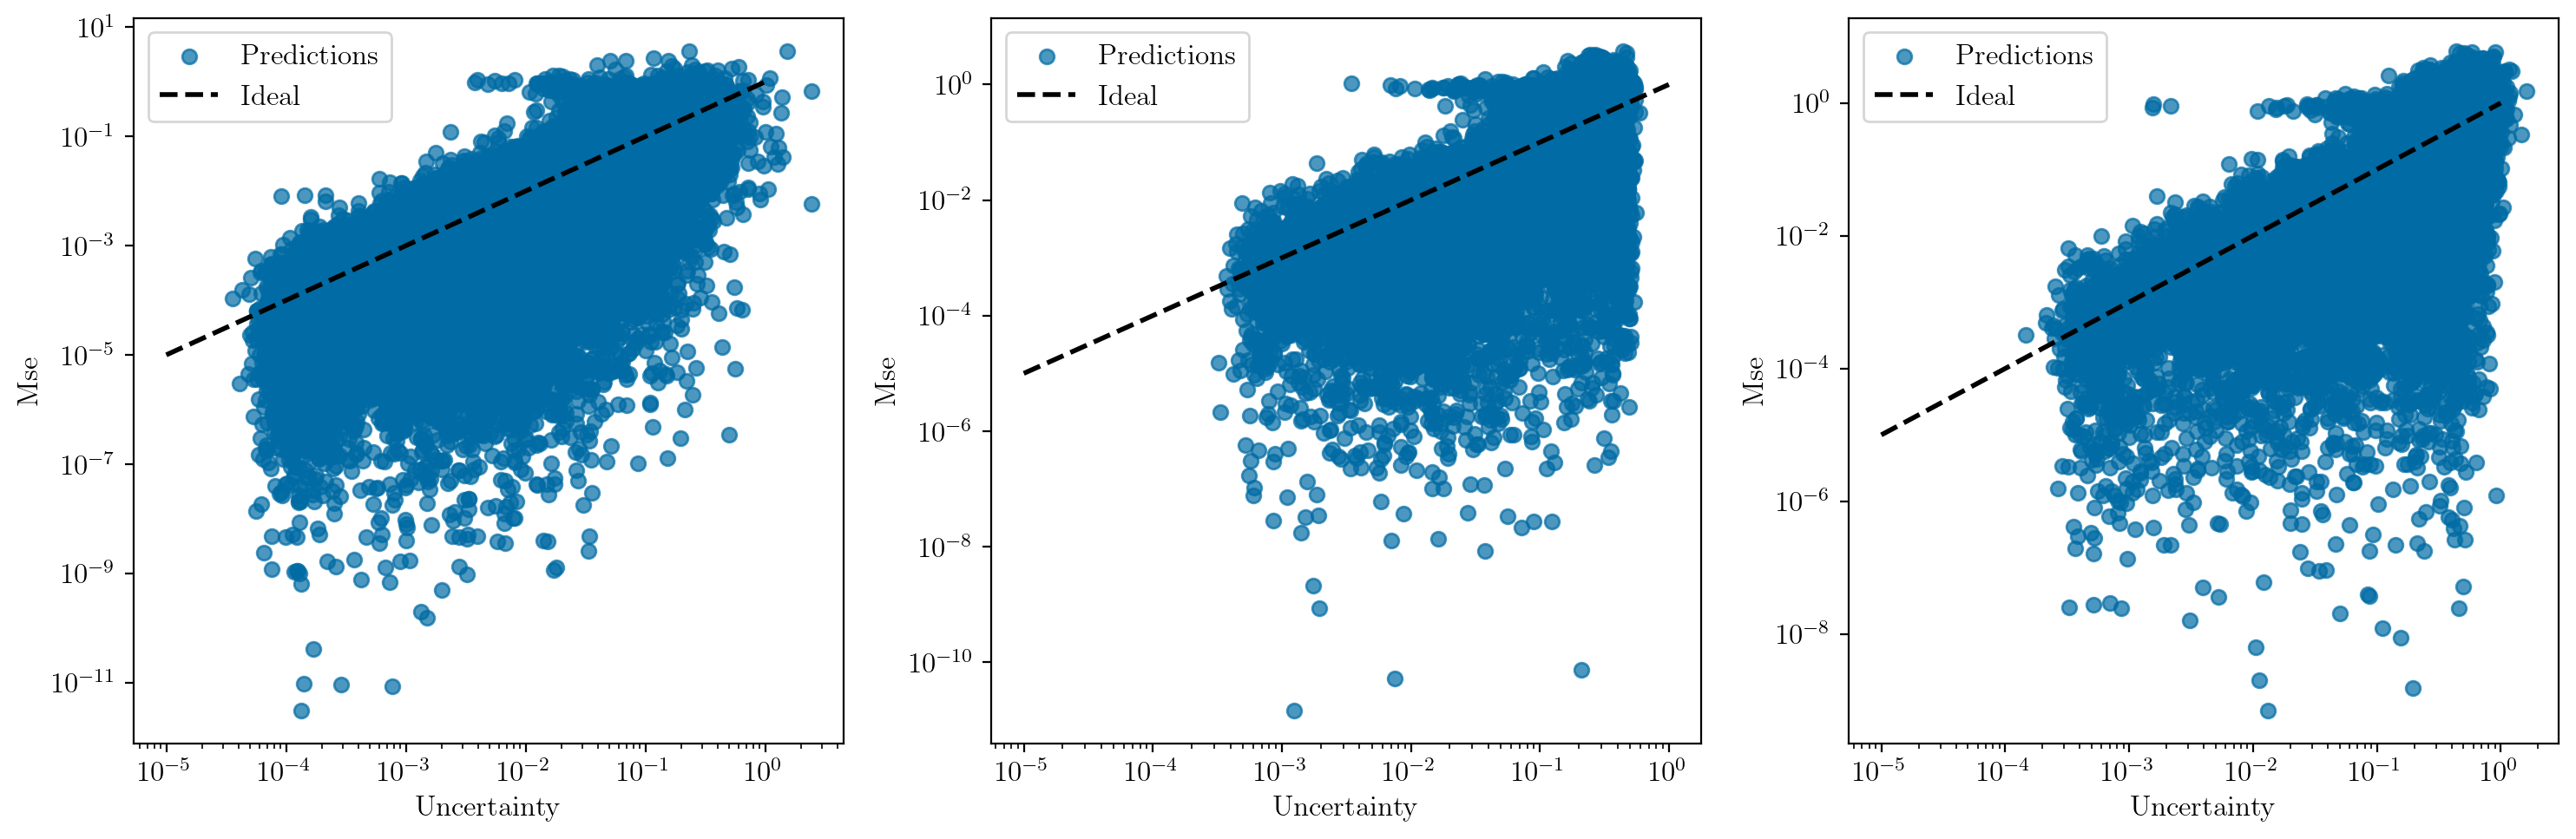

In [7]:
# Aggregate scatter plots for predictions vs. true values
plt.figure(figsize=(15, 5))
for i in range(y_train.shape[1]):
    plt.subplot(1, 3, i + 1)
    plt.scatter(data_uncertainty[:, i], (y_test[:, i]- preds[:, i])**2, alpha=0.7, label="Predictions")
    # plt.errorbar(y_test[:, i], preds[:, i], xerr=data_uncertainty[:, i],alpha=0.7, label="Predictions", fmt=".")
    plt.plot([1e-5,1 ], [1e-5,1], 'k--', lw=2, label="Ideal")
    # plt.title(f"Predicted vs True Values for Target {i+1}")
    plt.xlabel("Uncertainty")
    plt.ylabel("Mse")
    plt.legend()
    plt.yscale("log")
    plt.xscale("log")
plt.tight_layout()
plt.show()

# Training Threshold

In [10]:
preds_train = []
data_uncertainty_train = []
knowledge_uncertainty_train = []

for i in range(y_train.shape[1]):
    
    model = models[i]

    # Generate predictions with uncertainty
    pred_train = model.virtual_ensembles_predict(X_train_new[::10], prediction_type='TotalUncertainty', virtual_ensembles_count=10)
    preds_train.append(pred_train[:, 0])  # Mean predictions
    data_uncertainty_train.append(pred_train[:, 2])  # Data uncertainty
    knowledge_uncertainty_train.append(pred_train[:, 1])  # Knowledge uncertainty

# Convert lists to arrays for easier manipulation
preds_train = np.column_stack(preds_train)
data_uncertainty_train = np.column_stack(data_uncertainty_train)
knowledge_uncertainty_train = np.column_stack(knowledge_uncertainty_train)

In [11]:
optimized_thresholds = utils_ml.optimize_thresholds(preds_train, y_train[::10], class_to_poles)
print("Optimized Thresholds:", optimized_thresholds)

Optimization result:        message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -0.507968253968254
             x: [ 4.945e-01  5.043e-01 ...  4.981e-01  4.184e-01]
           nit: 240
          nfev: 645
 final_simplex: (array([[ 4.945e-01,  5.043e-01, ...,  4.981e-01,
                         4.184e-01],
                       [ 4.945e-01,  5.043e-01, ...,  4.981e-01,
                         4.184e-01],
                       ...,
                       [ 4.945e-01,  5.043e-01, ...,  4.981e-01,
                         4.184e-01],
                       [ 4.945e-01,  5.043e-01, ...,  4.981e-01,
                         4.184e-01]]), array([-5.080e-01, -5.080e-01, ..., -5.079e-01, -5.079e-01]))
Optimized Thresholds: [0.49454662 0.50429435 0.50476063 0.49867458 0.50102739 0.5032329
 0.50225834 0.46854229 0.49795987 0.50235195 0.50395526 0.50767362
 0.50780312 0.50913825 0.5023321  0.5023676  0.5032818  0.50970797
 0.49746124 0.50782977

In [14]:
adjusted_preds_train = utils_ml.round_with_thresholds(preds_train, optimized_thresholds, class_to_poles)

res_ = np.sum(np.sum(np.round(preds_train) == y_train[::10], axis=1) == 3)/y_train.shape[0]
print(f"Test Accuracy Baselie: {np.mean(res_):.4f}")

res_ = np.sum(np.sum(adjusted_preds_train == y_train[::10], axis=1) == 3)/y_train.shape[0]
print(f"Test Accuracy Improved: {np.mean(res_):.4f}")

Test Accuracy Baselie: 0.0503
Test Accuracy Improved: 0.0508


In [15]:
adjusted_preds = utils_ml.round_with_thresholds(preds, optimized_thresholds, class_to_poles)

res_ = np.sum(np.sum(np.round(preds) == y_test, axis=1) == 3)/y_test.shape[0]
print(f"Test Accuracy Baselie: {np.mean(res_):.4f}")

res_ = np.sum(np.sum(adjusted_preds == y_test, axis=1) == 3)/y_test.shape[0]
print(f"Test Accuracy Improved: {np.mean(res_):.4f}")

Test Accuracy Baselie: 0.5029
Test Accuracy Improved: 0.5076


# Removing

/tmp/ipykernel_144754/1583747594.py:22: RuntimeWarning: invalid value encountered in scalar divide
  acc = np.sum(remaining_true == np.round(remaining_preds)) /remaining_preds.shape[0]


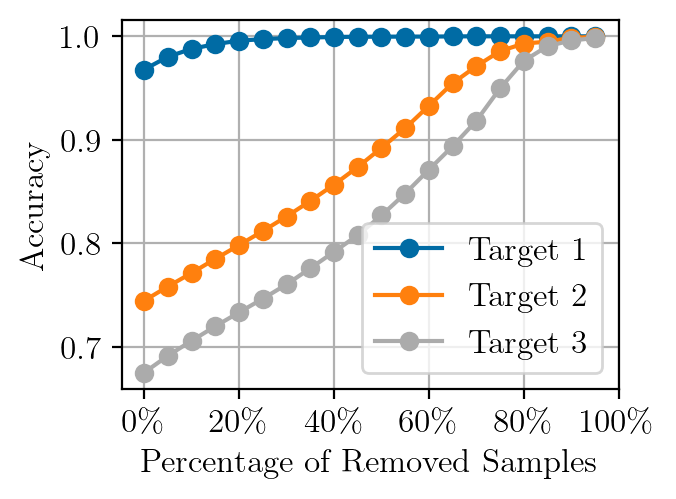

In [10]:
# Sort the data by uncertainty for each target
mse_changes = []
percent_removed = []

for i in range(y_train.shape[1]):
    sorted_indices = np.argsort(data_uncertainty[:, i])[::-1] 
    sorted_uncertainties = data_uncertainty[sorted_indices, i]
    sorted_true = y_test[sorted_indices, i]
    sorted_preds = preds[sorted_indices, i]

    # Calculate the MSE after removing samples with the highest uncertainty
    acc_list = []
    percent_list = []
    total_samples = len(sorted_uncertainties)

    for remove_percent in range(0, 101, 5):  # Remove in 5% increments
        num_remove = int(total_samples * (remove_percent / 100))
        remaining_true = sorted_true[num_remove:]
        remaining_preds = sorted_preds[num_remove:]

        # mse = np.mean((remaining_true - remaining_preds) ** 2)  # Calculate MSE
        acc = np.sum(remaining_true == np.round(remaining_preds)) /remaining_preds.shape[0]
        acc_list.append(acc)
        percent_list.append(remove_percent)
        

    mse_changes.append(acc_list)
    percent_removed.append(percent_list)

# Plot the results
# plt.figure(figsize=(15, 5))
fig, axs = plt.subplots(1,figsize=(3.54331, 3.54331*0.75))

for i in range(y_train.shape[1]):
    axs.plot(percent_removed[i], mse_changes[i],"-o", label=f"Pole Idx {i+1}")
axs.set_xlabel("Percentage of Rejected Samples")
axs.set_ylabel("Accuracy")
# axs.set_title("Impact of Removing High-Uncertainty Samples on Acc")
axs.legend()
axs.set_xticks([0, 20, 40, 60, 80, 100])
axs.set_xticklabels([f"{int(p)}\%" for p in [0, 20, 40, 60, 80, 100]])
axs.grid(True)
fig.tight_layout() # samples 
# fig.show()

# Hist

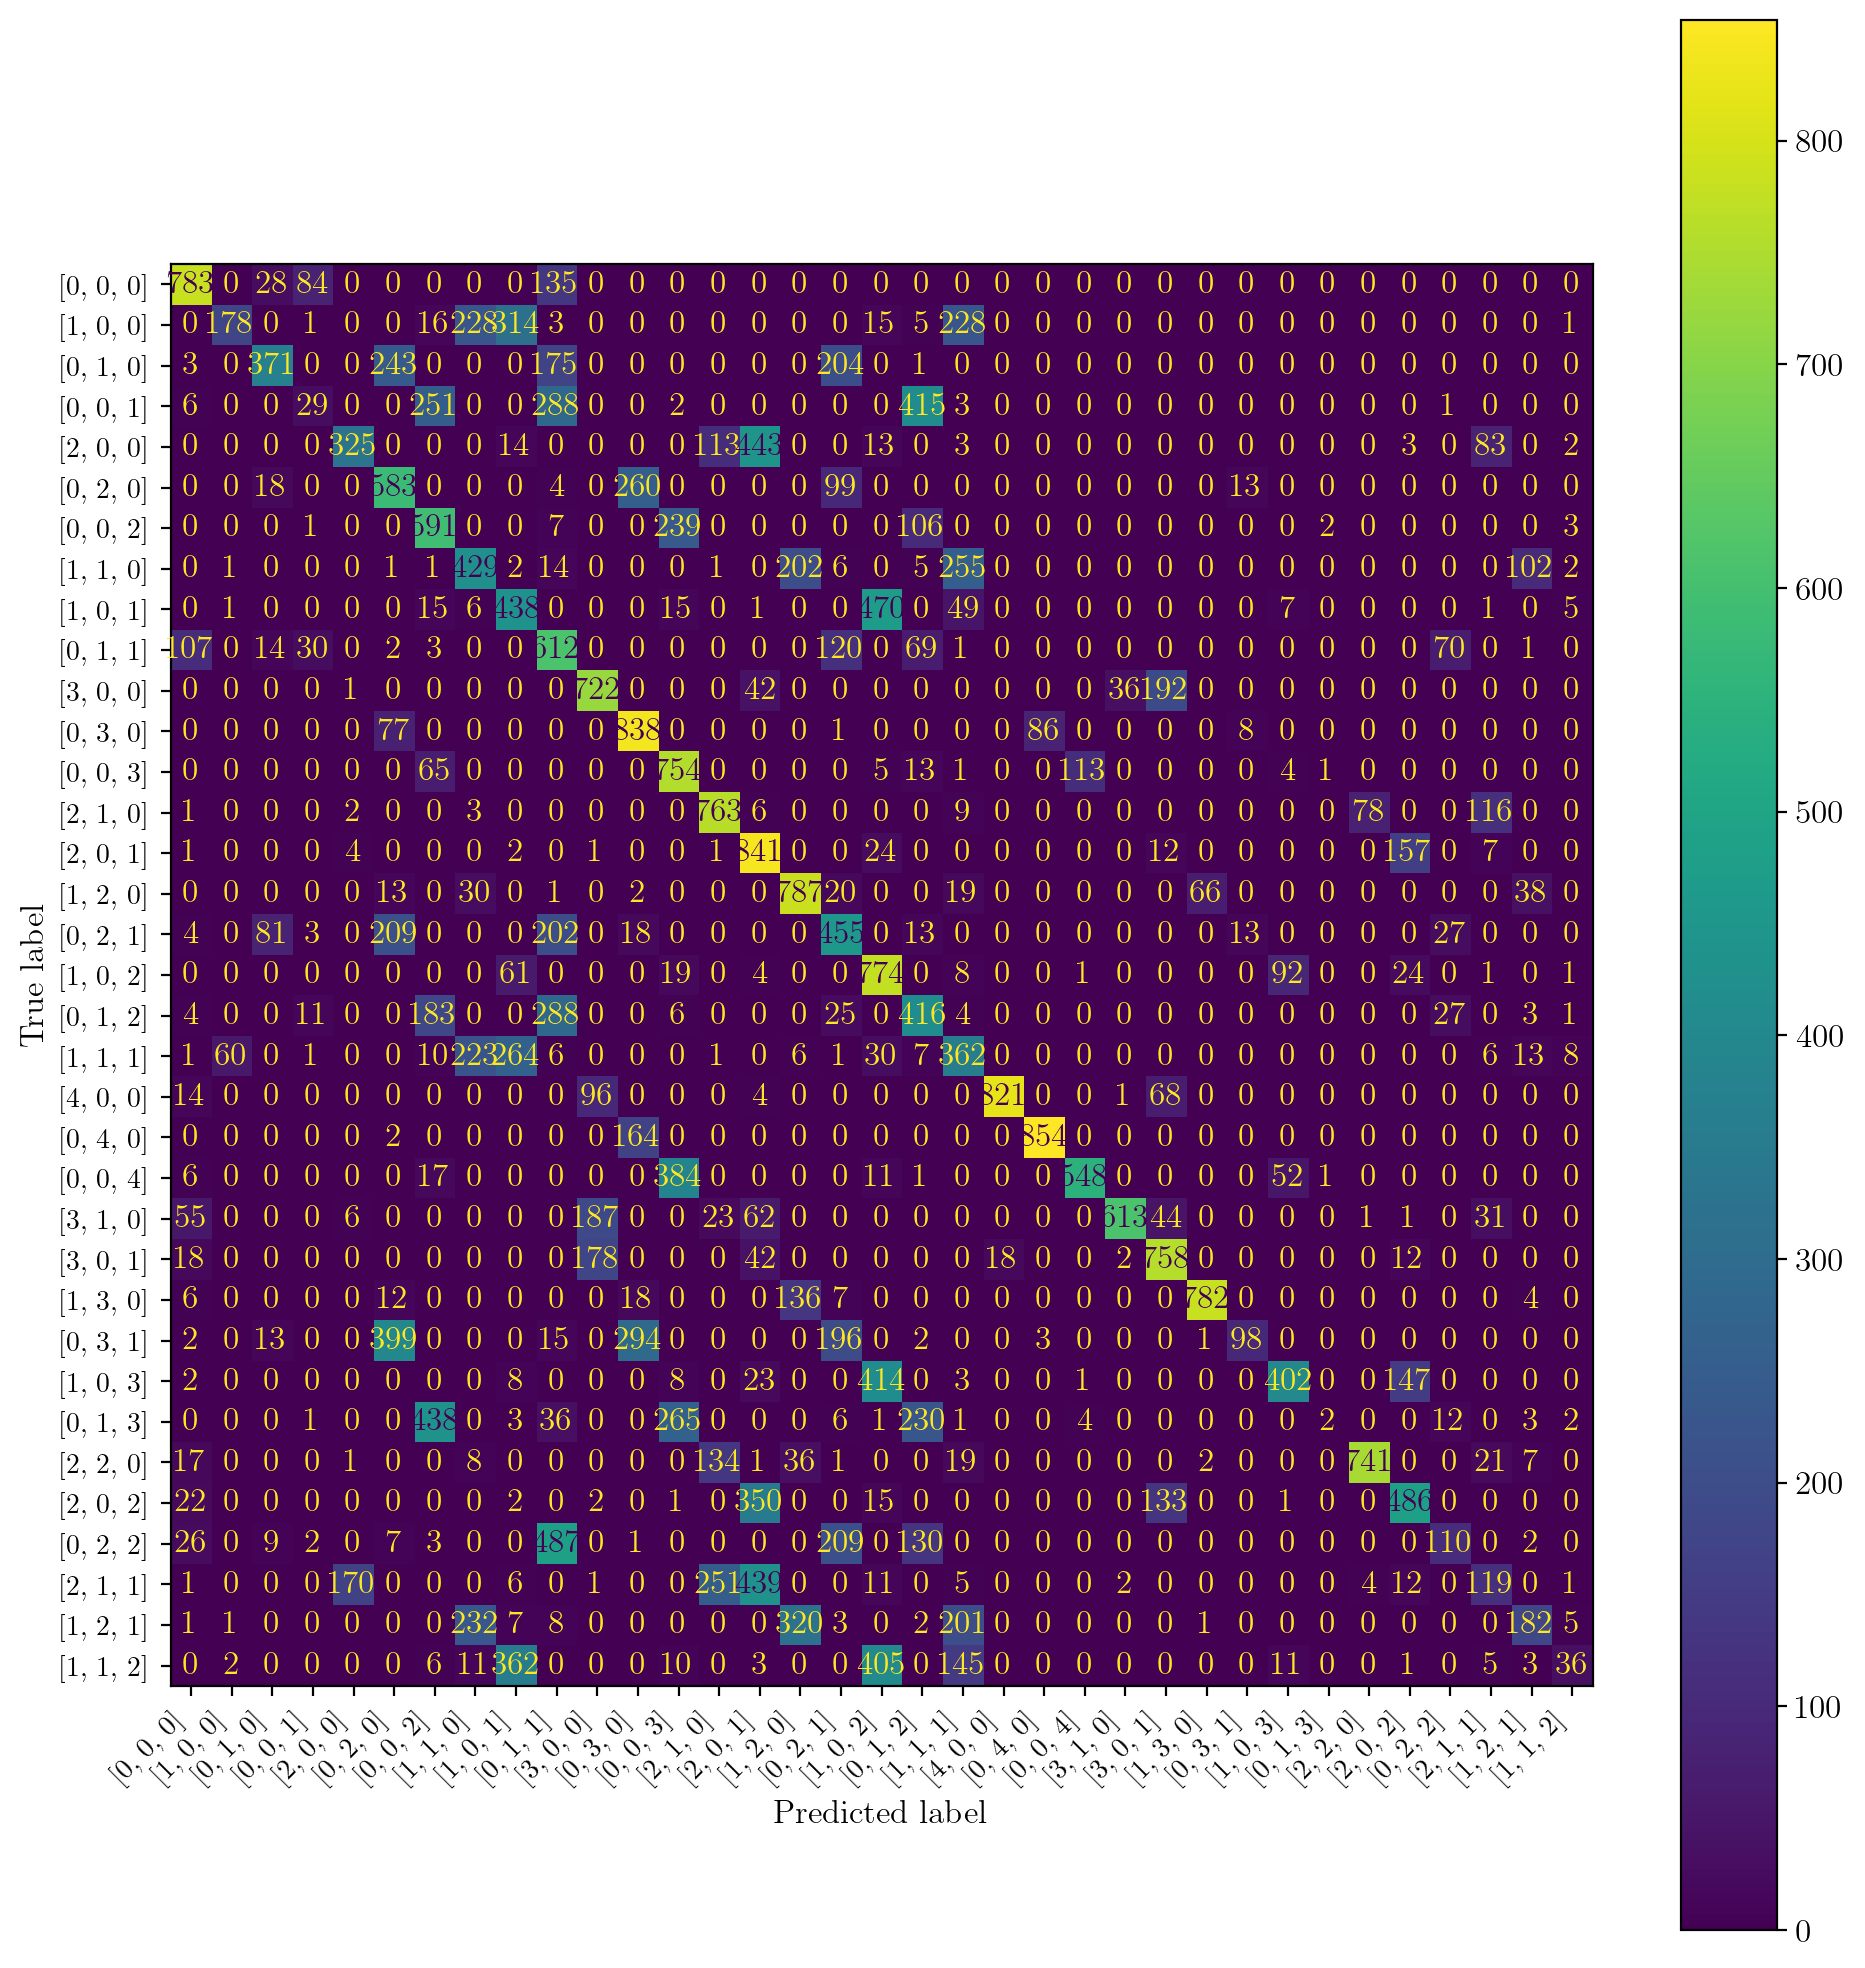

In [20]:
# fig, axs = plt.subplots(1,3)

# axs[0].hist((preds[:,0]))
# axs[0].hist(y_test[:,0],zorder=0)

# axs[1].hist((preds[:,1]))
# axs[1].hist(y_test[:,1],zorder=0)

# axs[2].hist((preds[:,2]))
# axs[2].hist(y_test[:,2],zorder=0)

# fig.tight_layout()

# fig, axs = plt.subplots(1,3)

# axs[0].hist(np.round(preds[:,0]))
# axs[0].hist(y_test[:,0],zorder=0)

# axs[1].hist(np.round(preds[:,1]))
# axs[1].hist(y_test[:,1],zorder=0)

# axs[2].hist(np.round(preds[:,2]))
# axs[2].hist(y_test[:,2],zorder=0)

# fig.tight_layout()


# custom_labels = [str(class_to_poles[i]) for i in range(len(class_to_poles))]

# # Compute the confusion matrix
# predictions = utils_ml.reconvert_labels(np.abs(np.round(preds)).tolist(), class_to_poles)
# cm = confusion_matrix(utils_ml.reconvert_labels(y_test, class_to_poles), predictions, labels=np.arange(len(class_to_poles)))

# # Plot the confusion matrix
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(len(class_to_poles)))
fig, ax = plt.subplots(figsize=(10, 10))  # Adjust figure size if needed
disp.plot(ax=ax)

# Update x and y axis tick labels with the custom labels
ax.set_xticks(np.arange(len(custom_labels)))
ax.set_yticks(np.arange(len(custom_labels)))
ax.set_xticklabels(custom_labels, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(custom_labels, fontsize=10)

# Adjust layout for readability
plt.tight_layout()
plt.show()